# ML Course Season 2
## Практика: Подбор гиперпараметров и интерпретируемость моделей

В этом ноутбуке мы:
1. Подберём гиперпараметры нескольких моделей с помощью Grid Search и Random Search
2. Настроим Pipeline с совместным подбором препроцессинга и модели
3. Интерпретируем результаты через Permutation Importance, PDP/ICE и SHAP
4. Научимся диагностировать подозрительные признаки

**Датасет:** [Wine Quality](https://scikit-learn.org/stable/datasets/toy_dataset.html) и Breast Cancer Wisconsin (sklearn)

---

## Шаг 1. Импорты и загрузка данных

Загрузим датасет Breast Cancer Wisconsin и познакомимся с ним.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_colwidth', None)

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

# Загружаем датасет
data = load_breast_cancer(as_frame=True)
X, y = data.data, data.target
feature_names = data.feature_names

print(data.DESCR[:600])

.. _breast_cancer_dataset:

Breast cancer wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concav


In [2]:
# Разбиваем данные
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Распределение классов в train: {y_train.value_counts().to_dict()}")

Train: (455, 30), Test: (114, 30)
Распределение классов в train: {1: 285, 0: 170}


## Шаг 2. Базовые модели без тюнинга

Обучим несколько моделей с дефолтными параметрами, чтобы иметь точку отсчёта.

In [3]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import f1_score

# Словарь базовых моделей
base_models = {
    'SVM': Pipeline([('scaler', StandardScaler()), ('clf', SVC(random_state=42))]),
    'RandomForest': RandomForestClassifier(random_state=42),
    'LogisticRegression': Pipeline([('scaler', StandardScaler()),
                                    ('clf', LogisticRegression(random_state=42))]),
}

baseline_results = {}

# ╔══════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 2а: Для каждой модели в base_models         ║
# ║  вычислите 5-fold CV с scoring='f1_macro'            ║
# ║  Сохраните mean и std в baseline_results             ║
# ╚══════════════════════════════════════════════════════╝

# YOUR CODE HERE
for model_name, model in base_models.items():
  score = cross_val_score(model, X_train, y_train, cv=5, scoring = 'f1_macro')
  baseline_results[model_name] = (score.mean(), score.std())


# После заполнения — вывод результатов:
for name, (mean, std) in baseline_results.items():
    print(f"{name:25s} F1 = {mean:.4f} ± {std:.4f}")

SVM                       F1 = 0.9694 ± 0.0193
RandomForest              F1 = 0.9504 ± 0.0255
LogisticRegression        F1 = 0.9787 ± 0.0139


## Шаг 3. Grid Search для SVM

Подберём гиперпараметры SVM с помощью перебора сетки через Pipeline.

In [4]:
from sklearn.model_selection import GridSearchCV

# Pipeline: нормировка + SVM
svm_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(random_state=42, probability=True)),
])

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 3а: Задайте сетку параметров для GridSearchCV       ║
# ║  Параметры SVM через Pipeline: 'svm__C', 'svm__gamma',       ║
# ║  'svm__kernel'                                               ║
# ║  Попробуйте: C in [0.1, 1, 10, 100],                        ║
# ║  gamma in ['scale', 0.01, 0.001], kernel in ['rbf','linear'] ║
# ╚══════════════════════════════════════════════════════════════╝

svm_param_grid = {
    # YOUR CODE HERE
    'svm__C': [0.1, 1, 10, 100],
    'svm__gamma': ['scale', 0.01, 0.001],
    'svm__kernel': ['rbf', 'linear']

}

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 3б: Создайте и запустите GridSearchCV               ║
# ║  cv=5, scoring='f1_macro', n_jobs=-1                         ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
svm_grid_search = GridSearchCV(svm_pipe, svm_param_grid, cv = 5, scoring = 'f1_macro', n_jobs = -1)
svm_grid_search.fit(X_train, y_train)

print(f"Лучшие параметры SVM: {svm_grid_search.best_params_}")
print(f"Лучший CV F1: {svm_grid_search.best_score_:.4f}")

Лучшие параметры SVM: {'svm__C': 10, 'svm__gamma': 0.01, 'svm__kernel': 'rbf'}
Лучший CV F1: 0.9786


In [5]:
# Анализируем результаты Grid Search

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 3в: Создайте DataFrame из svm_grid_search.cv_results║
# ║  Выберите колонки: params, mean_test_score, std_test_score,  ║
# ║  rank_test_score                                             ║
# ║  Выведите топ-10 конфигураций                                ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
cv_results_df = pd.DataFrame(svm_grid_search.cv_results_)
cv_results_df.sort_values('rank_test_score', inplace = True)
to_print = cv_results_df[['params','mean_test_score','std_test_score','rank_test_score']]
print(to_print.head(10))

                                                             params  \
14         {'svm__C': 10, 'svm__gamma': 0.01, 'svm__kernel': 'rbf'}   
1   {'svm__C': 0.1, 'svm__gamma': 'scale', 'svm__kernel': 'linear'}   
5     {'svm__C': 0.1, 'svm__gamma': 0.001, 'svm__kernel': 'linear'}   
3      {'svm__C': 0.1, 'svm__gamma': 0.01, 'svm__kernel': 'linear'}   
22       {'svm__C': 100, 'svm__gamma': 0.001, 'svm__kernel': 'rbf'}   
16        {'svm__C': 10, 'svm__gamma': 0.001, 'svm__kernel': 'rbf'}   
6        {'svm__C': 1, 'svm__gamma': 'scale', 'svm__kernel': 'rbf'}   
12      {'svm__C': 10, 'svm__gamma': 'scale', 'svm__kernel': 'rbf'}   
20        {'svm__C': 100, 'svm__gamma': 0.01, 'svm__kernel': 'rbf'}   
8           {'svm__C': 1, 'svm__gamma': 0.01, 'svm__kernel': 'rbf'}   

    mean_test_score  std_test_score  rank_test_score  
14         0.978633        0.017581                1  
1          0.976215        0.015266                2  
5          0.976215        0.015266                2 

## Шаг 4. Random Search для RandomForest

Теперь подберём гиперпараметры RandomForest с помощью случайного поиска.

In [6]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, loguniform

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 4а: Задайте пространство параметров для             ║
# ║  RandomizedSearchCV на RandomForestClassifier                ║
# ║  Попробуйте:                                                 ║
# ║    n_estimators: randint(50, 500)                            ║
# ║    max_depth: randint(2, 20) или None                        ║
# ║    min_samples_split: randint(2, 20)                         ║
# ║    max_features: ['sqrt', 'log2', 0.5]                       ║
# ╚══════════════════════════════════════════════════════════════╝

rf_param_dist = {
    # YOUR CODE HERE
    'n_estimators': randint(50, 500),
    'max_depth': randint(2, 20),
    'min_samples_split': randint(2, 20),
    'max_features': ['sqrt', 'log2', 0.5]
}

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 4б: Создайте RandomizedSearchCV                     ║
# ║  n_iter=50, cv=5, scoring='f1_macro',                        ║
# ║  random_state=42, n_jobs=-1                                  ║
# ║  Обучите на X_train, y_train                                 ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
random_forest_model = RandomForestClassifier(random_state = 42)
rf_random_search = RandomizedSearchCV(random_forest_model, rf_param_dist, n_iter=50, cv = 5, scoring = 'f1_macro', random_state = 42, n_jobs = -1)
rf_random_search.fit(X_train, y_train)

print(f"Лучшие параметры RF: {rf_random_search.best_params_}")
print(f"Лучший CV F1: {rf_random_search.best_score_:.4f}")

Лучшие параметры RF: {'max_depth': 8, 'max_features': 'log2', 'min_samples_split': 2, 'n_estimators': 434}
Лучший CV F1: 0.9554


## Шаг 5. Сравнение результатов

Сравним: baseline vs Grid Search vs Random Search. И проведём финальную оценку на тесте.

In [29]:
from sklearn.metrics import classification_report

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 5: Оцените лучшие модели (svm_grid_search и         ║
# ║  rf_random_search) на тестовой выборке X_test, y_test        ║
# ║                                                              ║
# ║  Для каждой модели выведите classification_report            ║
# ║  Сравните с baseline моделями из шага 2                      ║
# ║                                                              ║
# ║  ВАЖНО: тест используем ТОЛЬКО ЗДЕСЬ, один раз!             ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
# предикт для моделей с тюнингом
y_pred_svm = svm_grid_search.predict(X_test)
y_pred_rf = rf_random_search.predict(X_test)

# фит и предикт для моделей без тюнинга
base_models['SVM'].fit(X_train, y_train)
base_models['RandomForest'].fit(X_train, y_train)
y_pred_svm_baseline = base_models['SVM'].predict(X_test)
y_pred_rf_baseline = base_models['RandomForest'].predict(X_test)

#метрики f1 (для всех и с тюнингом и без)
svm_baseline_score_f1 = f1_score(y_test, y_pred_svm_baseline, average = 'macro')
rf_baseline_score_f1 = f1_score(y_test, y_pred_rf_baseline, average = 'macro')
svm_score_f1 = f1_score(y_test, y_pred_svm, average='macro')
rf_score_f1 = f1_score(y_test, y_pred_rf, average='macro')


svm_baseline_cv_mean, svm_baseline_cv_std = baseline_results['SVM']
svm_best_index = svm_grid_search.best_index_
svm_cv_mean = svm_grid_search.cv_results_['mean_test_score'][svm_best_index]
svm_cv_std = svm_grid_search.cv_results_['std_test_score'][svm_best_index]

rf_baseline_cv_mean, rf_baseline_cv_std = baseline_results['RandomForest']
rf_best_index = rf_random_search.best_index_
rf_cv_mean = rf_random_search.cv_results_['mean_test_score'][rf_best_index]
rf_cv_std = rf_random_search.cv_results_['std_test_score'][rf_best_index]

print("| Модель                | CV F1 (mean±std)  | Test F1 |")
print("|-----------------------|-------------------|---------|")
print(f"| SVM baseline          | {svm_baseline_cv_mean:.4f} +/- {svm_baseline_cv_std:.4f} | {svm_baseline_score_f1:.4f}  |")
print(f"| SVM Grid Search       | {svm_cv_mean:.4f} +/- {svm_cv_std:.4f} | {svm_score_f1:.4f}  |")
print(f"| RF baseline           | {rf_baseline_cv_mean:.4f} +/- {rf_baseline_cv_std:.4f} | {rf_baseline_score_f1:.4f}  |")
print(f"| RF Random Search      | {rf_cv_mean:.4f} +/- {rf_cv_std:.4f} | {rf_score_f1:.4f}  |")



print(f"\nsvm report:\n {classification_report(y_test, y_pred_svm)}")
print(f"\nrandom forest report:\n {classification_report(y_test, y_pred_rf)}")

# Заполните таблицу:
# | Модель                | CV F1 (mean±std) | Test F1 |
# |-----------------------|------------------|---------|
# | SVM baseline          |                  |         |
# | SVM Grid Search       |                  |         |
# | RF baseline           |                  |         |
# | RF Random Search      |                  |         |

| Модель                | CV F1 (mean±std)  | Test F1 |
|-----------------------|-------------------|---------|
| SVM baseline          | 0.9694 +/- 0.0193 | 0.9812  |
| SVM Grid Search       | 0.9786 +/- 0.0176 | 0.9812  |
| RF baseline           | 0.9504 +/- 0.0255 | 0.9526  |
| RF Random Search      | 0.9554 +/- 0.0204 | 0.9526  |

svm report:
               precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114


random forest report:
               precision    recall  f1-score   support

           0       0.95      0.93      0.94        42
           1       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96    

## Шаг 6. Permutation Importance

Посмотрим, какие признаки важны для лучшей модели.

топ-10 признаков по Permutation Importance:
1. worst area: 0.0101
2. worst concave points: 0.0083
3. worst texture: 0.0064
4. mean smoothness: 0.0055
5. mean area: 0.0055
6. worst concavity: 0.0046
7. mean texture: 0.0037
8. mean concave points: 0.0037
9. mean perimeter: 0.0028
10. mean radius: 0.0028


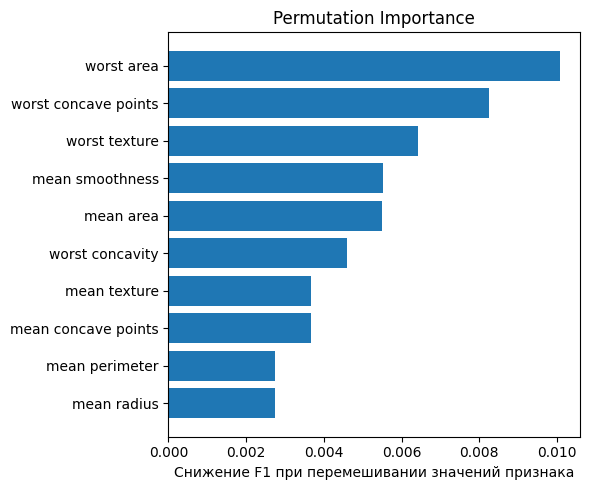

In [37]:
from sklearn.inspection import permutation_importance

# Используем лучший RF из Random Search
best_rf = rf_random_search.best_estimator_

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 6а: Вычислите Permutation Importance                ║
# ║  для best_rf на X_test, y_test                               ║
# ║  n_repeats=10, random_state=42, scoring='f1_macro'           ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
pi_result = permutation_importance(best_rf, X_test, y_test, n_repeats = 10, random_state = 42, scoring = 'f1_macro')
feature_list = pi_result.importances_mean.argsort()[::-1][:10]

print("топ-10 признаков по Permutation Importance:")
for i, feature in enumerate(feature_list):
    print(f"{i+1}. {feature_names[feature]}: {pi_result.importances_mean[feature]:.4f}")

# Построим bar plot топ-10 признаков
# YOUR CODE HERE
plt.figure(figsize=(6, 5))
plt.barh([feature_names[i] for i in feature_list[::-1]], pi_result.importances_mean[feature_list[::-1]])
plt.xlabel('Снижение F1 при перемешивании значений признака')
plt.title('Permutation Importance')
plt.tight_layout()
plt.show()

In [39]:
# Встроенная важность RF (для сравнения)

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 6б: Сравните Permutation Importance                 ║
# ║  с встроенной feature_importances_ RandomForest              ║
# ║  Совпадает ли порядок топ-5 признаков?                       ║
# ║  Если нет — как вы это объясняете?                           ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
rf_feature_importances = best_rf.feature_importances_
feature_list2 = rf_feature_importances.argsort()[::-1][:10]

print("топ-10 признаков по Feature Importance:")
for i, feature in enumerate(feature_list2):
    print(f"{i+1}. {feature_names[feature]}: {rf_feature_importances[feature]:.4f}")


# Вопрос для размышления:
# Некоторые признаки имеют высокий PI, но низкую встроенную важность,
# или наоборот. Что это может означать?

топ-10 признаков по Feature Importance:
1. worst area: 0.1271
2. worst perimeter: 0.1142
3. worst concave points: 0.1093
4. worst radius: 0.0825
5. mean concave points: 0.0722
6. mean radius: 0.0584
7. mean area: 0.0546
8. mean perimeter: 0.0533
9. mean concavity: 0.0521
10. area error: 0.0443


# ОТВЕТЫ
топ 5 не совпадает

PI характеризует то насколько упадет качество если признак сломать.
Feature importances в свою очередь показывает насколько часто данный признк используется в сплитах внутри деревьев.

Высокий PI и низкая встроенная важность - признак редко используется в сплитах(?)

Низкий PI и высокая важность говорит что признак коррелирует с еще каким то признаком. Оба из них могут использоваться в деревьях, но перемешивание одного из двух сильного влияния не окажет так как остался второй(это как раз и объясняет низкий PI)

## Шаг 7. PDP и ICE-кривые

Визуализируем эффект наиболее важных признаков.

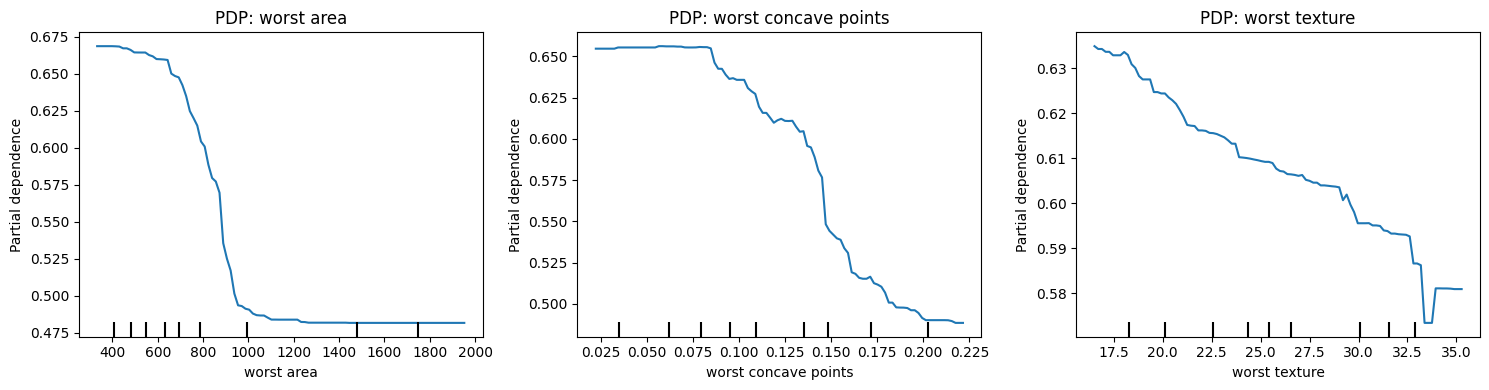

In [41]:
from sklearn.inspection import PartialDependenceDisplay

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 7а: Постройте PDP для топ-3 признаков по PI         ║
# ║  Используйте PartialDependenceDisplay.from_estimator         ║
# ║  kind='average' для PDP                                      ║
# ╚══════════════════════════════════════════════════════════════╝

# Определите индексы топ-3 признаков по PI
top3_idx = pi_result.importances_mean.argsort()[::-1][:3]

# Постройте PDP
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
# YOUR CODE HERE
for i, idx in enumerate(top3_idx):
    PartialDependenceDisplay.from_estimator(best_rf, X_test, [idx], kind='average', ax=axes[i], feature_names=feature_names)
    axes[i].set_title(f'PDP: {feature_names[idx]}')
plt.tight_layout()
plt.show()

на первом отчетливо виден пороговый эффект. больше площадь больше вероятность 0 то бишь опухоли

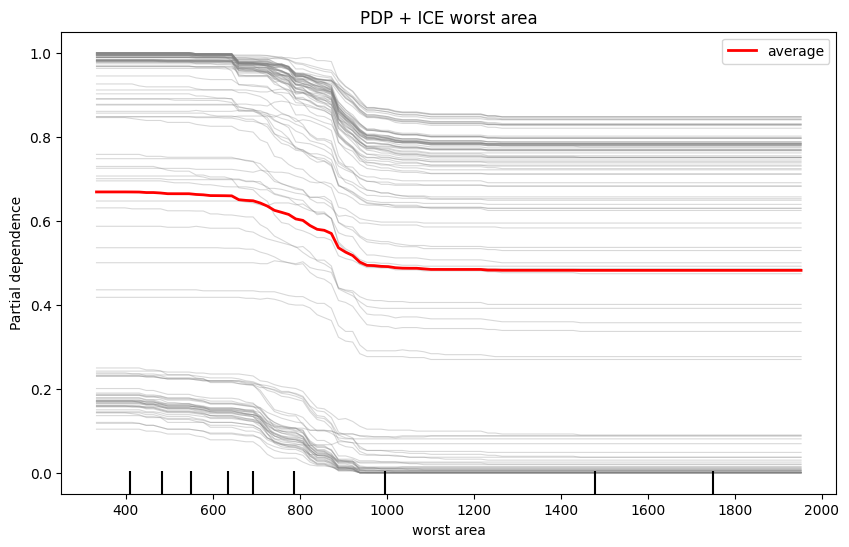

In [45]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 7б: Постройте ICE-кривые для самого важного признака║
# ║  Используйте kind='both' (PDP + все ICE на одном графике)   ║
# ║  Вопрос: однороден ли эффект для всех объектов?              ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
top1_idx = pi_result.importances_mean.argsort()[::-1][0]

# PDP + ICE (все объекты)
fig, ax = plt.subplots(figsize=(10, 6))
PartialDependenceDisplay.from_estimator(best_rf, X_test, [top1_idx],kind='both', ax=ax, feature_names=feature_names,
    ice_lines_kw={'alpha': 0.3, 'linewidth': 0.8, 'color': 'gray', 'linestyle': '-'},
    pd_line_kw={'color': 'red', 'linewidth': 2, 'linestyle': '-'}
)
ax.set_title(f'PDP + ICE {feature_names[top1_idx]}')
ax.set_xlabel(feature_names[top1_idx])
plt.show()

# ОТВЕТ
да эффект однороден. для всех вероятность того что опухоль доброкачественна падает

## Шаг 8. SHAP

Интерпретируем модель с помощью SHAP — глобально и локально.

In [51]:
# Установка SHAP (если не установлен)
# !pip install shap

import shap

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 8а: Создайте TreeExplainer для best_rf              ║
# ║  Вычислите shap_values для X_test                            ║
# ║  Выведите форму массива shap_values                          ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
explainer = shap.TreeExplainer(best_rf)
shap_values = explainer.shap_values(X_test)
print(f"shap_values shape: {shap_values.shape}")

shap_values shape: (114, 30, 2)


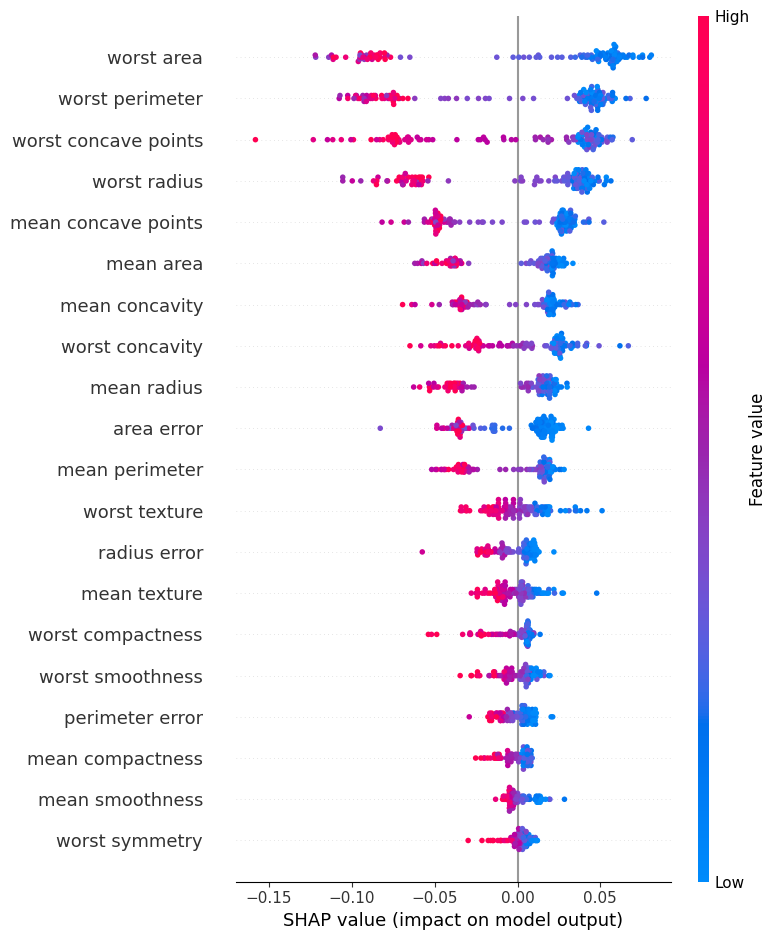

In [61]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 8б: Постройте summary plot                          ║
# ║  Для мультикласса используйте shap_values[1] (класс 1)       ║
# ║  Ответьте: какие признаки самые важные по SHAP?              ║
# ║  Совпадает ли с PI из шага 6?                                ║
# ╚══════════════════════════════════════════════════════════════╝
shap.summary_plot(shap_values[:, :, 1], X_test)

# YOUR CODE HERE

частично подобны, но не идентичны

In [65]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 8в: Найдите объект, на котором модель ошиблась      ║
# ║  (y_pred != y_test). Постройте для него force_plot           ║
# ║  Какие признаки «виноваты» в ошибке?                         ║
# ╚══════════════════════════════════════════════════════════════╝

y_pred_test = best_rf.predict(X_test)
errors = np.where(y_pred_test != y_test)[0]

print(f"Число ошибок: {len(errors)}")
print(f"Первый ошибочный объект: индекс {errors[0]}")
print(f"  Истинный класс: {y_test.iloc[errors[0]]}")
print(f"  Предсказанный класс: {y_pred_test[errors[0]]}")

# YOUR CODE HERE
shap.initjs()
shap.force_plot(explainer.expected_value[1], shap_values[:, :, 1][errors[0]], X_test.iloc[errors[0]])

Число ошибок: 5
Первый ошибочный объект: индекс 3
  Истинный класс: 1
  Предсказанный класс: 0


виноваты признаки обозначенные синим такие как worst area, worst radius, worst perimetr... за их счет предсказание смещалось к 0(то бишь больному)

## Шаг 9. Диагностика подозрительных признаков

Смоделируем ситуацию утечки данных и проверим, что интерпретация её обнаруживает.

In [66]:
# Добавим два «подозрительных» признака:
# 1. leaky_feature: почти полностью совпадает с таргетом + шум
# 2. random_feature: случайный шум, не связан с таргетом

np.random.seed(42)
X_train_ext = X_train.copy()
X_test_ext = X_test.copy()

X_train_ext['leaky_feature'] = y_train + np.random.normal(0, 0.1, len(y_train))
X_test_ext['leaky_feature'] = y_test + np.random.normal(0, 0.1, len(y_test))

X_train_ext['random_feature'] = np.random.randn(len(y_train))
X_test_ext['random_feature'] = np.random.randn(len(y_test))

print("Добавлены признаки: leaky_feature, random_feature")
print(X_train_ext.tail())

Добавлены признаки: leaky_feature, random_feature
     mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
184        15.28         22.41           98.92      710.6          0.09057   
300        19.53         18.90          129.50     1217.0          0.11500   
509        15.46         23.95          103.80      731.3          0.11830   
230        17.05         19.08          113.40      895.0          0.11410   
474        10.88         15.62           70.41      358.9          0.10070   

     mean compactness  mean concavity  mean concave points  mean symmetry  \
184            0.1052         0.05375              0.03263         0.1727   
300            0.1642         0.21970              0.10620         0.1792   
509            0.1870         0.20300              0.08520         0.1807   
230            0.1572         0.19100              0.10900         0.2131   
474            0.1069         0.05115              0.01571         0.1861   

     mean fractal 

In [111]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 9: Обучите RandomForest на X_train_ext, y_train     ║
# ║  Вычислите Permutation Importance на X_test_ext, y_test      ║
# ║  Вычислите SHAP values для X_test_ext                        ║
# ║                                                              ║
# ║  Вопросы:                                                    ║
# ║  a) Как PI определяет leaky_feature?                         ║
# ║     Почему метрика на тесте выросла?                         ║
# ║  б) Как SHAP выделяет leaky_feature в summary plot?          ║
# ║  в) Как обнаружить random_feature как «шумовой»?             ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
rf_ext = RandomForestClassifier(random_state=42)
rf_ext.fit(X_train_ext, y_train)
pi_ext = permutation_importance(rf_ext, X_test_ext, y_test, n_repeats=10, random_state=42, scoring='f1_macro')
sorted_idx_ext = pi_ext.importances_mean.argsort()[::-1][:10]
feature_names_ext = list(X_train_ext.columns)

print("Топ-10 по PI на расширенных данных:")
for i, idx in enumerate(sorted_idx_ext):
    print(f"{i+1}. {feature_names_ext[idx]}: {pi_ext.importances_mean[idx]:.4f}")

Топ-10 по PI на расширенных данных:
1. leaky_feature: 0.2633
2. mean concave points: 0.0047
3. worst concave points: 0.0038
4. worst fractal dimension: 0.0000
5. worst symmetry: 0.0000
6. worst concavity: 0.0000
7. worst compactness: 0.0000
8. random_feature: 0.0000
9. worst area: 0.0000
10. worst perimeter: 0.0000


Leaky_feature определяется как очень важный признак. метрика выросла потому что таргет буквально был внесен как признак(с небольшим шумом почти всегда в пределах -0.1 ... 0.1)

На почти все остальные признаки модели стало все равно

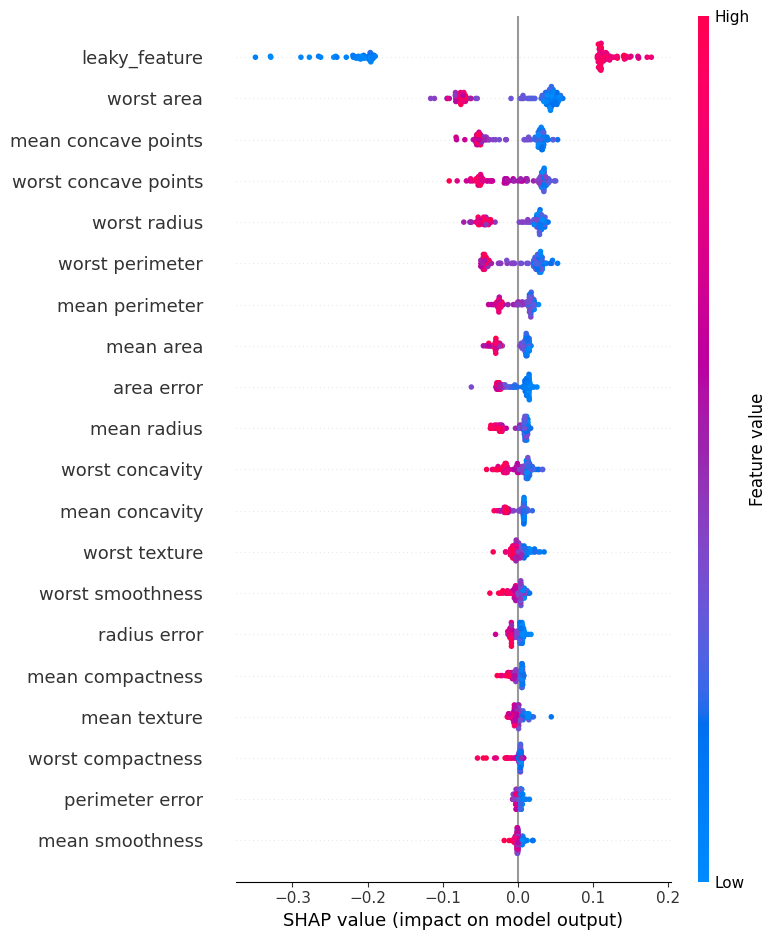

In [112]:
explainer_ext = shap.TreeExplainer(rf_ext)
shap_values_ext = explainer_ext.shap_values(X_test_ext)

shap.summary_plot(shap_values_ext[:, :, 1], X_test_ext, feature_names=names_ext)

на первом месте параметр с утечкой. к тому же он всегда вносит большой импакт(в обе стороны). виден большой разрыв между импактом в обе стороны

In [80]:
random_idx = names_ext.index('random_feature')
worst_area_idx = names_ext.index('worst area')
leaky_idx = names_ext.index('leaky_feature')
print(f"Среднее значение модуля по SHAP для random_feature: {np.abs(shap_values_ext[:, :, 1][:, random_idx]).mean():.4f}")
print(f"Среднее значение модуля по SHAP для worst area:     {np.abs(shap_values_ext[:, :, 1][:, worst_area_idx]).mean():.4f}")
print(f"Среднее значение модуля по SHAP для leaky_feature:  {np.abs(shap_values_ext[:, :, 1][:, leaky_idx]).mean():.4f}")

Среднее значение модуля по SHAP для random_feature: 0.0006
Среднее значение модуля по SHAP для worst area:     0.0522
Среднее значение модуля по SHAP для leaky_feature:  0.1582


random_feature это шум так как можно видеть random_feature вносит ОЧЕНЬ малый импакт. 87 раз меньше чем вносил самый важный по shap параметр до расширения сетки параметров. и в 264 раза меньше чем слитый таргет.

## Шаг 10. Сводная таблица и итоги

Соберём все результаты и сформулируем выводы.

In [91]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 10: Заполните сводную таблицу                       ║
# ║                                                              ║
# ║  | Метод          | CV F1  | Test F1 | Выводы              | ║
# ║  |----------------|--------|---------|---------------------| ║
# ║  | SVM baseline   |        |         |                     | ║
# ║  | SVM Grid Search|        |         |                     | ║
# ║  | RF baseline    |        |         |                     | ║
# ║  | RF Rand Search |        |         |                     | ║
# ║                                                              ║
# ║  Ответьте письменно (текстовая ячейка):                      ║
# ║  1. Насколько тюнинг улучшил модели?                         ║
# ║  2. Совпадают ли топ-признаки по PI и SHAP?                  ║
# ║     Если нет — почему?                                       ║
# ║  3. Что было бы, если бы мы не использовали Pipeline?        ║
# ║  4. Как бы вы использовали PI и SHAP в реальном проекте?     ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
print("| Модель                | CV F1 (mean±std)  | Test F1 | Выводы(?)")
print("|-----------------------|-------------------|---------|")
print(f"| SVM baseline          | {svm_baseline_cv_mean:.4f} +/- {svm_baseline_cv_std:.4f} | {svm_baseline_score_f1:.4f}  |")
print(f"| SVM Grid Search       | {svm_cv_mean:.4f} +/- {svm_cv_std:.4f} | {svm_score_f1:.4f}  | тюнинг дал прирост по cv и снизил std но на тесте не отразился. baseline - ок")
print(f"| RF baseline           | {rf_baseline_cv_mean:.4f} +/- {rf_baseline_cv_std:.4f} | {rf_baseline_score_f1:.4f}  | svm показал себя лучше чем random forest")
print(f"| RF Random Search      | {rf_cv_mean:.4f} +/- {rf_cv_std:.4f} | {rf_score_f1:.4f}  | тюнинг дал прирост по cv и снизил std но на тесте не отразился. baseline - ок")

| Модель                | CV F1 (mean±std)  | Test F1 | Выводы(?)
|-----------------------|-------------------|---------|
| SVM baseline          | 0.9694 +/- 0.0193 | 0.9812  |
| SVM Grid Search       | 0.9786 +/- 0.0176 | 0.9812  | тюнинг дал прирост по cv и снизил std но на тесте не отразился. baseline - ок
| RF baseline           | 0.9504 +/- 0.0255 | 0.9526  | svm показал себя лучше чем random forest
| RF Random Search      | 0.9554 +/- 0.0204 | 0.9526  | тюнинг дал прирост по cv и снизил std но на тесте не отразился. baseline - ок


# ОТВЕТЫ
1. Тюнинг в обоих случаях дал прирост по метрике f1 и снижение стандартного отклонения на кросс валидационных тестах. однако на тесте это не отразилось. модель без тюнинга показала себя хорошо.

2. Топ признаки по PI и SHAP не совпадают. Точнее совпдает только первый. Дело как мне кажется их природе. IP демонстрирует как изменяется проноз если признак сломать. Это изменение начальных данных.
Shap же считается непосредтсвенно во время обучения и показывает как часто признак используется деревьями чтобы делать сплиты. В данном случае списки признаков не совпадают, выше описывал частные случаи "высокий - низкий". Если вспомнить матрицу корреляций для датасета с раком груди(у меня она насколько я помню точно должна быть в ноутбуке с наивным байесом) то часть признаков так коррелироала друг с другом. В частности это может объяснять разницу списков.

3. Была бы утечка данных при масштабироавнии. scaler бы видел валидационный фолд.

4. Наверное для определения признаков представляющих исключительно шум и невносящих импакта. force_plot подходит для объяснения решения.

## Шаг 11. (Бонус) Bayesian Optimization с Optuna

Если осталось время — сравните Random Search и Optuna по скорости сходимости.

In [86]:
!pip install optuna

In [90]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ╔══════════════════════════════════════════════════════════════╗
# ║  БОНУС: Реализуйте objective-функцию для Optuna              ║
# ║  Используйте те же параметры, что в Random Search            ║
# ║  Запустите study.optimize с n_trials=50                      ║
# ║                                                              ║
# ║  Постройте график сходимости:                                ║
# ║  plt.plot(range(n_trials), best_values_over_time)            ║
# ║  Сравните кривые Optuna и Random Search (если логировали)    ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 500),
        'max_depth': trial.suggest_int('max_depth', 2, 20),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', 0.5])
    }
    model = RandomForestClassifier(**params, random_state=42)
    score = cross_val_score(model, X_train, y_train, cv=5, scoring='f1_macro').mean()
    return score

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)
print(f"Лучший результат Optuna: {study.best_value:.4f}")
print(f"Лучшие параметры: {study.best_params}")

Лучший результат Optuna: 0.9577
Лучшие параметры: {'n_estimators': 122, 'max_depth': 10, 'min_samples_split': 3, 'max_features': 0.5}


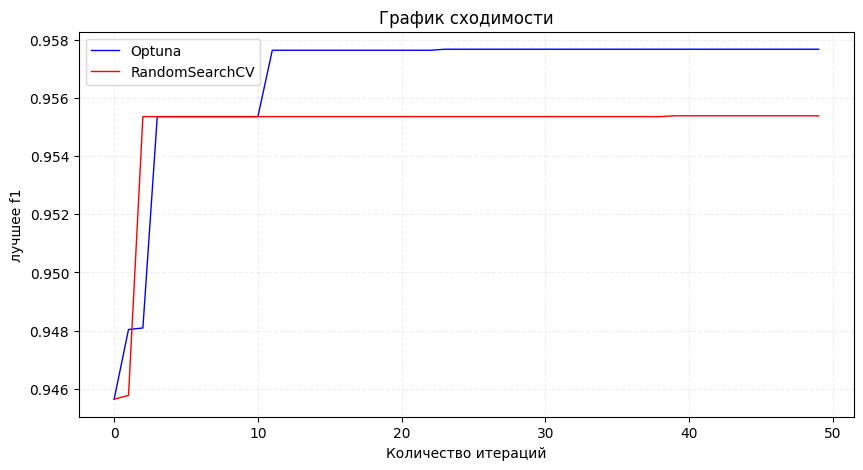

In [109]:
# набор значений для графика сход optuna
optuna_best_values_over_time = []
current_best = 0
for trial in study.trials:
    if trial.value is not None and trial.value > current_best:
        current_best = trial.value
    optuna_best_values_over_time.append(current_best)


#для random search
random_search_best_values_over_time = []
current_best = 0
for trial in rf_random_search.cv_results_['mean_test_score']:
    if trial is not None and trial > current_best:
        current_best = trial
    random_search_best_values_over_time.append(current_best)


plt.figure(figsize=(10, 5))
plt.plot(range(50), optuna_best_values_over_time, label='Optuna', color='blue', linewidth=1)
plt.plot(range(50), random_search_best_values_over_time, label='RandomSearchCV', color='red', linewidth=1)
plt.xlabel('Количество итераций')
plt.ylabel('лучшее f1')
plt.title('График сходимости')
plt.grid(True, linestyle='--', alpha=0.2)
plt.legend()
plt.show()

# НАБЛЮДЕНИЕ
RandomSearchCV к своему максимум сошелся раньше. Но его топовый f1 ниже чем тот который был подобран optuna